In [1]:
import pandas as pd 
import numpy as np 
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import warnings as wr
wr.filterwarnings('ignore')


In [2]:
data = pd.read_csv('Churn_Modelling.csv')

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
data.shape

(10000, 14)

In [5]:
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [6]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
le = LabelEncoder()

In [8]:
data['Gender']=le.fit_transform(data['Gender'])
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [9]:
#ohe = OneHotEncoder(drop = 'first')

In [10]:
#geo_encoded =ohe.fit_transform(data[['Geography']]).toarray()
#geo_encoded_df =pd.DataFrame(geo_encoded ,columns=ohe.get_feature_names_out(['Geography']))
geo_encoded_df = pd.get_dummies(data['Geography'], prefix='Geography', dtype=int,drop_first=True)
geo_encoded_df

,Geography_Germany,Geography_Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,1,0


In [11]:
data = pd.concat([data.drop(columns=['Geography']),geo_encoded_df],axis=1)

In [12]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [13]:
data.shape

(10000, 12)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [15]:
exited_counts= data['Exited'].value_counts()

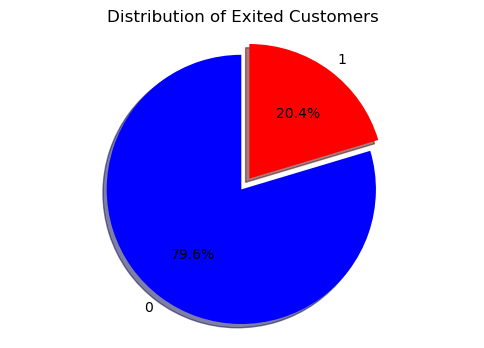

In [16]:
plt.figure(figsize=(6,4))
plt.pie(exited_counts,
        labels=exited_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['blue','red'],
        explode=(0,0.1),
        shadow= True)
plt.title('Distribution of Exited Customers')
plt.axis('equal')
plt.show()

In [17]:
data.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


In [18]:
x=data.drop(columns=['Exited'],axis=1)
y=data[['Exited']]

In [19]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [20]:
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1


In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=42)

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred=clf.predict(x_test)

In [25]:
accuracy_score(y_test,y_pred)

0.8113333333333334

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
clf_ran = RandomForestClassifier(n_estimators=155)


In [28]:
clf_ran.fit(x_train, y_train)

,n_estimators,155
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
x_test

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
6252,596,1,32,3,96709.07,2,0,0,41788.37,1,0
4684,623,1,43,1,0.00,2,1,1,146379.30,0,0
1731,601,0,44,4,0.00,2,1,0,58561.31,0,1
4742,506,1,59,8,119152.10,2,1,1,170679.74,1,0
4521,560,0,27,7,124995.98,1,1,1,114669.79,0,1
...,...,...,...,...,...,...,...,...,...,...,...
8014,731,0,39,2,126816.18,1,1,1,74850.93,0,1
1074,535,0,31,7,111855.04,2,1,1,36278.89,0,0
3063,609,1,32,7,71872.19,1,1,1,151924.90,0,0
6487,580,1,31,2,0.00,2,0,1,64014.24,0,0


In [29]:
ran_pred = clf_ran.predict(x_test)
ran_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

In [30]:
accuracy_score(y_test,ran_pred)

0.8676666666666667

Confusion Matrix 

In [31]:
cm_ran = confusion_matrix(y_test, ran_pred)

In [32]:
cm_ran

array([[2330,   86],
       [ 311,  273]])

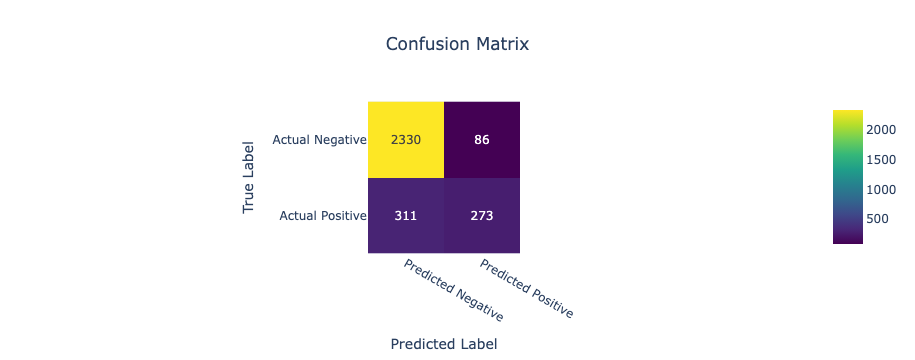

In [33]:
cm_df = pd.DataFrame(cm_ran, index=['Actual Negative', 'Actual Positive'], 
                     columns=['Predicted Negative', 'Predicted Positive'])

fig = px.imshow(cm_df, 
                text_auto=True, 
                color_continuous_scale="Viridis", 
                title="Confusion Matrix")

fig.update_layout(
    title={
        'text': "Confusion Matrix",
        'x': 0.5, 
        'xanchor': 'center' 
    },
    
    xaxis_title="Predicted Label",
    yaxis_title="True Label",
    coloraxis_showscale=True
)
fig.show()

In [35]:
import pickle as pk
with open('My_Model1','wb') as file:
    pk.dump(ran_pred,file)

In [37]:
pk.dump(clf_ran,open('My_Model2','wb'))

In [38]:
import joblib as jbl

In [39]:
jbl.dump(clf_ran,'My_Model3')

['My_Model3']